# Math for AI - Week 2
A hands-on notebook covering three core math concepts every AI engineer needs:
1. Matrix multiplication from scratch
2. Naiv Bayes spam classifier from scratch
3. Central Limit Theorem simulation

 ## 1. Matrix Multiplication from Scratch

 Matrix multiplication: for matrices A(mxn) and B(nxp),
 each element C[i][j] = sum of A[i,:] * B[:,j] (dot product of row i with column j).

 Rule: columns of A MUST be equal to rows of B

In [3]:
def matrix_multiply_scratch(A, B):
    """Multiplies two matrices A and B using nested loops.

    Args:
        A: A 2D list representing the first matrix.
        B: A 2D list representing the second matrix.)

    Returns:
        A 2D list representing the product of A and B.
    """

    rows_A = len(A)
    cols_A = len(A[0])
    rows_B = len(B)
    cols_B = len(B[0])

    if cols_A != rows_B:
        raise ValueError("Number of columns in A must be equal to number of rows in B.")

    # Initialize the result matrix with zeros
    result = [[0 for _ in range(cols_B)] for _ in range(rows_A)]

    # Perform matrix multiplication
    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                result[i][j] += A[i][k] * B[k][j]

    return result

A = [[1, 2, 3], [4, 5, 6]]
B = [[7, 8], [9, 10], [11, 12]]
result = matrix_multiply_scratch(A, B)

print(result)

# matrix multiplication using numpy
import numpy as np
A_np = np.array(A)
B_np = np.array(B)
result_np = np.dot(A_np, B_np)
print(result_np.tolist())

[[58, 64], [139, 154]]
[[58, 64], [139, 154]]


In [7]:
import time

# Measure the time taken by the scratch implementation
size = 200
A_big = [[float(i*size + j) for j in range(size)] for i in range(size)]
B_big = [[float(i*size + j) for j in range(size)] for i in range(size)]

A_big_np = np.array(A_big)
B_big_np = np.array(B_big)

start_time = time.time()
result_big_scratch = matrix_multiply_scratch(A_big, B_big)
scratch_time = time.time() - start_time

start_time = time.time()
result_big_np = A_big_np @ B_big_np
numpy_time = time.time() - start_time

print(f"Time taken by scratch implementation: {scratch_time:.4f} seconds")
print(f"Time taken by NumPy implementation: {numpy_time:.4f} seconds")
print(f"numpy is {scratch_time / numpy_time:.2f} times faster than scratch implementation")

Time taken by scratch implementation: 0.5032 seconds
Time taken by NumPy implementation: 0.0001 seconds
numpy is 4027.94 times faster than scratch implementation


## 2. Naive Bayes Spam Classifier from Scratch

Bayes' theorem: P(spam | words) ∝ P(spam) × ∏ P(word | spam)

"Naive" = we assume each word is independent of every other word.
We use log probabilities to avoid floating point underflow 
(multiplying many small numbers → rounds to zero).

In [4]:
# Training data: (message, label)
# 1 = spam, 0 = ham (not spam)

training_data = [
    ("win free money now",          1),
    ("free prize claim now",        1),
    ("you won a lottery prize",     1),
    ("win cash prize today",        1),
    ("free offer click here",       1),
    ("claim your free gift now",    1),
    ("limited offer free money",    1),
    ("hey are you coming tomorrow", 0),
    ("lets meet for lunch today",   0),
    ("can you send me the report",  0),
    ("dinner at seven sounds good", 0),
    ("please review this document", 0),
    ("call me when you are free",   0),
    ("see you at the meeting",      0),
]

print(f"Total messages: {len(training_data)}")
print(f"Spam:  {sum(1 for _, l in training_data if l == 1)}")
print(f"Ham:   {sum(1 for _, l in training_data if l == 0)}")

Total messages: 14
Spam:  7
Ham:   7


In [8]:
import math
from collections import defaultdict

class NaiveBayesClassifier:
    def __init__(self, smoothing=1.0):
        """
        smoothing: Laplace smoothing — prevents zero probability
                   for words not seen during training.
        """
        self.smoothing = smoothing
        self.word_counts   = {0: defaultdict(int), 1: defaultdict(int)}
        self.class_counts  = {0: 0, 1: 0}
        self.vocab         = set()

    def train(self, data):
        """Count word occurrences per class."""
        for message, label in data:
            words = message.lower().split()
            self.class_counts[label] += 1
            for word in words:
                self.word_counts[label][word] += 1
                self.vocab.add(word)

        print(f"Trained on {sum(self.class_counts.values())} messages")
        print(f"Vocabulary size: {len(self.vocab)} unique words")
        print(f"Class counts: spam={self.class_counts[1]}, "
              f"ham={self.class_counts[0]}")
        
    def _word_log_prob(self, word, label):
        """
        Log probability of a word given a class.
        Uses Laplace smoothing to handle unseen words.

        P(word|class) = (count(word, class) + smoothing)
                      / (total_words_in_class + smoothing * vocab_size)
        """
        count      = self.word_counts[label][word] + self.smoothing
        total      = (sum(self.word_counts[label].values())
                      + self.smoothing * len(self.vocab))
        return math.log(count / total)
    
    def predict(self, message):
        """
        Compute log P(class) + sum of log P(word|class) for each class.
        Return the class with the higher score.
        """
        total = sum(self.class_counts.values())
        words = message.lower().split()

        scores = {}
        for label in [0, 1]:
            # Prior: how common is this class overall?
            log_prior = math.log(self.class_counts[label] / total)

            # Likelihood: how likely are these words given the class?
            log_likelihood = sum(
                self._word_log_prob(word, label) for word in words
            )

            scores[label] = log_prior + log_likelihood

        predicted = max(scores, key=scores.get)

        # Convert log scores to probabilities for readability
        max_score  = max(scores.values())
        exp_scores = {k: math.exp(v - max_score) for k, v in scores.items()}
        total_exp  = sum(exp_scores.values())
        probs      = {k: v / total_exp for k, v in exp_scores.items()}

        return predicted, probs
    
    def evaluate(self, test_data):
        """Run predictions on a test set and print results."""
        correct = 0
        print(f"\n{'Message':<35} {'Actual':<8} {'Predicted':<10} {'Spam %'}")
        print("-" * 70)
        for message, actual in test_data:
            pred, probs = self.predict(message)
            correct += (pred == actual)
            status = "✓" if pred == actual else "✗"
            label_map = {0: "ham", 1: "spam"}
            print(f"{message:<35} {label_map[actual]:<8} "
                  f"{label_map[pred]:<10} "
                  f"{probs[1]*100:.1f}%  {status}")
        print(f"\nAccuracy: {correct}/{len(test_data)} "
              f"= {correct/len(test_data)*100:.0f}%")
        
# Train
clf = NaiveBayesClassifier(smoothing=1.0)
clf.train(training_data)

# Test messages the model has never seen
test_data = [
    ("free money win prize",        1),  # obvious spam
    ("click here free offer",       1),  # spam
    ("are you free for a call",     0),  # ham — contains "free" but not spam
    ("lets catch up tomorrow",      0),  # ham
    ("win free lottery today",      1),  # spam
    ("can we reschedule the call",  0),  # ham
]

clf.evaluate(test_data)

Trained on 14 messages
Vocabulary size: 44 unique words
Class counts: spam=7, ham=7

Message                             Actual   Predicted  Spam %
----------------------------------------------------------------------
free money win prize                spam     spam       99.3%  ✓
click here free offer               spam     spam       98.0%  ✓
are you free for a call             ham      ham        24.2%  ✓
lets catch up tomorrow              ham      ham        25.5%  ✓
win free lottery today              spam     spam       96.1%  ✓
can we reschedule the call          ham      ham        11.0%  ✓

Accuracy: 6/6 = 100%


In [9]:
print("\nTop 10 words most associated with SPAM:")
spam_words = sorted(
    clf.word_counts[1].items(),
    key=lambda x: x[1],
    reverse=True
)[:10]
for word, count in spam_words:
    print(f"  '{word}': {count} times")

print("\nTop 10 words most associated with HAM:")
ham_words = sorted(
    clf.word_counts[0].items(),
    key=lambda x: x[1],
    reverse=True
)[:10]
for word, count in ham_words:
    print(f"  '{word}': {count} times")


Top 10 words most associated with SPAM:
  'free': 5 times
  'now': 3 times
  'prize': 3 times
  'win': 2 times
  'money': 2 times
  'claim': 2 times
  'offer': 2 times
  'you': 1 times
  'won': 1 times
  'a': 1 times

Top 10 words most associated with HAM:
  'you': 4 times
  'are': 2 times
  'me': 2 times
  'the': 2 times
  'at': 2 times
  'hey': 1 times
  'coming': 1 times
  'tomorrow': 1 times
  'lets': 1 times
  'meet': 1 times


## 3. Central Limit Theorem Simulation

The Central Limit Theorem states:
"If you take many samples from ANY distribution and compute their means,
those means will follow a normal distribution — regardless of the
shape of the original distribution."

We'll prove this visually with three very different source distributions.

Exponential (right-skewed)
  Source mean: 1.980, std: 1.974
  Means  mean: 1.999, std: 0.345

Uniform (flat)
  Source mean: 4.968, std: 2.896
  Means  mean: 5.006, std: 0.528

Binomial (discrete, skewed)
  Source mean: 1.988, std: 1.229
  Means  mean: 1.990, std: 0.228



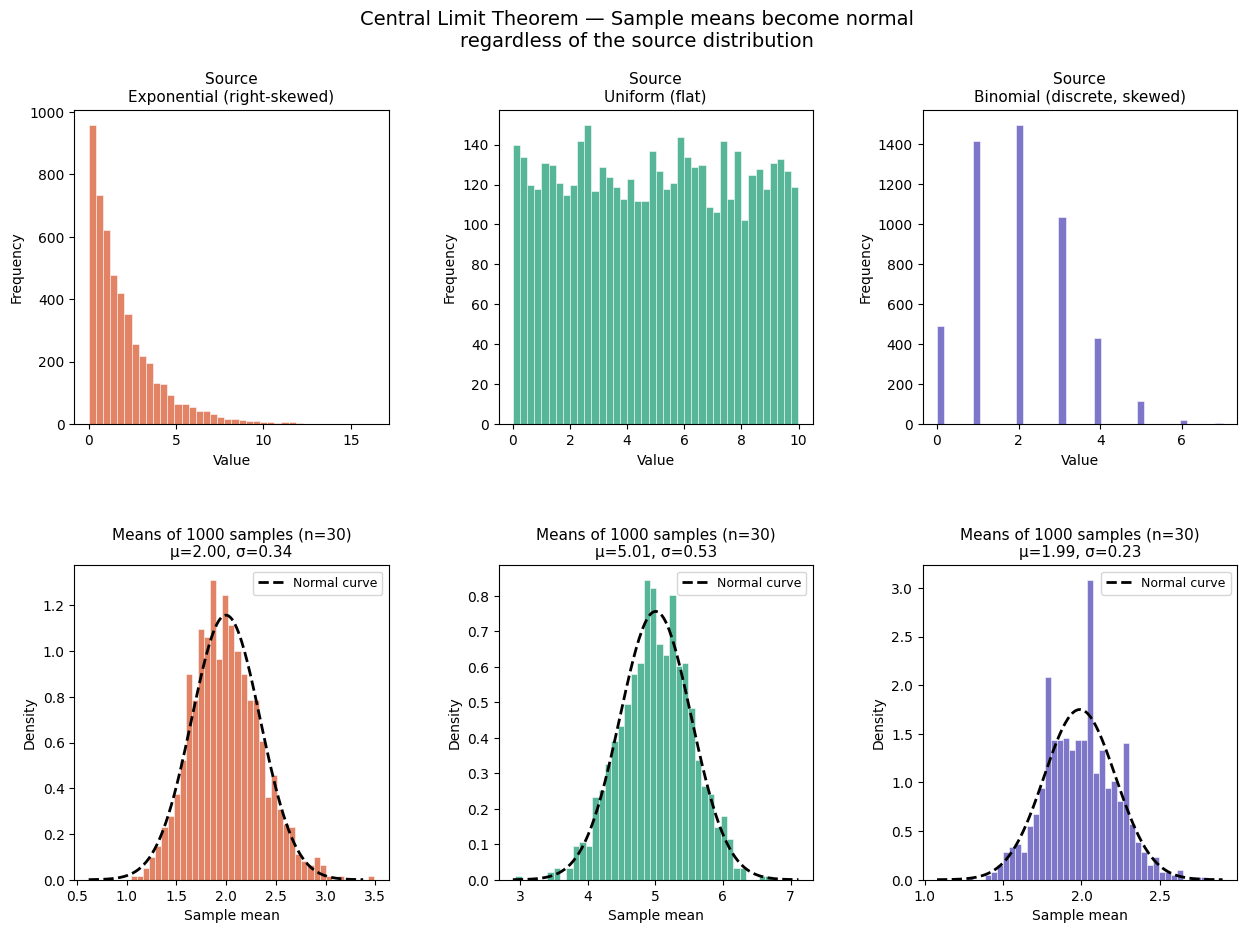

Saved as clt_simulation.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(42)

def simulate_clt(distribution_fn, dist_name, n_experiments=1000,
                 sample_size=30, color="#534AB7"):
    """
    distribution_fn: function returning an array of samples
    n_experiments:   how many times we draw a sample and compute its mean
    sample_size:     how many values in each sample
    """
    # Draw one large sample to show the source distribution
    source_sample = distribution_fn(5000)

    # Repeat: draw a sample, compute its mean
    sample_means = [
        np.mean(distribution_fn(sample_size))
        for _ in range(n_experiments)
    ]

    return source_sample, sample_means

# Three very different source distributions
distributions = [
    (lambda n: np.random.exponential(scale=2, size=n),
     "Exponential (right-skewed)", "#D85A30"),

    (lambda n: np.random.uniform(low=0, high=10, size=n),
     "Uniform (flat)", "#1D9E75"),

    (lambda n: np.random.binomial(n=10, p=0.2, size=n),
     "Binomial (discrete, skewed)", "#534AB7"),
]

results = []
for fn, name, color in distributions:
    source, means = simulate_clt(fn, name, color=color)
    results.append((source, means, name, color))
    print(f"{name}")
    print(f"  Source mean: {np.mean(source):.3f}, "
          f"std: {np.std(source):.3f}")
    print(f"  Means  mean: {np.mean(means):.3f}, "
          f"std: {np.std(means):.3f}")
    print()

# Plotting
fig = plt.figure(figsize=(15, 10))
fig.suptitle(
    "Central Limit Theorem — Sample means become normal\n"
    "regardless of the source distribution",
    fontsize=14, y=0.98
)

gs = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

for col, (source, means, name, color) in enumerate(results):

    # Top row: source distribution
    ax_top = fig.add_subplot(gs[0, col])
    ax_top.hist(source, bins=40, color=color, alpha=0.75,
                edgecolor="white", linewidth=0.5)
    ax_top.set_title(f"Source\n{name}", fontsize=11)
    ax_top.set_xlabel("Value")
    ax_top.set_ylabel("Frequency")

    # Bottom row: distribution of sample means
    ax_bot = fig.add_subplot(gs[1, col])
    ax_bot.hist(means, bins=40, color=color, alpha=0.75,
                edgecolor="white", linewidth=0.5, density=True)

    # Overlay the theoretical normal curve
    mu    = np.mean(means)
    sigma = np.std(means)
    x     = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    y     = (1 / (sigma * np.sqrt(2 * np.pi)) *
             np.exp(-0.5 * ((x - mu) / sigma)**2))
    ax_bot.plot(x, y, "k--", linewidth=2, label="Normal curve")
    ax_bot.set_title(
        f"Means of 1000 samples (n=30)\n"
        f"μ={mu:.2f}, σ={sigma:.2f}",
        fontsize=11
    )
    ax_bot.set_xlabel("Sample mean")
    ax_bot.set_ylabel("Density")
    ax_bot.legend(fontsize=9)

plt.savefig("clt_simulation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as clt_simulation.png")

## Key takeaways

- **Matrix multiplication**: every neural network forward pass is W @ x + b,
  repeated across layers. NumPy is ~1000x faster than pure Python loops.

- **Naive Bayes**: Bayes' theorem applied per-word, with log probabilities
  to avoid underflow. Works surprisingly well with tiny training data.

- **Central Limit Theorem**: no matter how skewed or weird your source
  distribution is, sample means always become normal as n grows.
  This is why normal distributions appear everywhere in AI.